Setup untuk Google Colab (T4 GPU)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import subprocess
result = subprocess.run(
    ["git", "clone",
     "https://github.com/Fawwzrf/PhishingDetector.git",
     "/content/ml_pipeline"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

fatal: destination path '/content/ml_pipeline' already exists and is not an empty directory.



In [2]:
!git pull origin main

%cd /content/ml_pipeline
!pip install -e . -q
!pip install -r requirements.txt -q

import mltools
print(f"mltools version: {mltools.__version__}")

fatal: not a git repository (or any of the parent directories): .git
/content/ml_pipeline
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mltools (pyproject.toml) ... done
mltools version: 1.0.0


In [ ]:
import os
import shutil
from pathlib import Path

DRIVE_PROJECT = "/content/drive/MyDrive/PhishingDetector"

Path(DRIVE_PROJECT).mkdir(parents=True, exist_ok=True)
for sub in ["data/raw", "data/interim", "data/processed",
            "models/preprocessing", "logs", "reports"]:
    Path(f"{DRIVE_PROJECT}/{sub}").mkdir(parents=True, exist_ok=True)

for folder in ["data", "models", "logs", "reports"]:
    local_path = f"/content/ml_pipeline/{folder}"
    drive_path = f"{DRIVE_PROJECT}/{folder}"

    if os.path.isdir(local_path) and not os.path.islink(local_path):
        shutil.rmtree(local_path)

    if not os.path.exists(local_path):
        os.symlink(drive_path, local_path)
        print(f"Symlink: {local_path} → {drive_path}")

print("\nStruktur folder:")
!ls -la /content/ml_pipeline/

Symlink: /content/ml_pipeline/data → /content/drive/MyDrive/PhishingDetector/data
Symlink: /content/ml_pipeline/models → /content/drive/MyDrive/PhishingDetector/models
Symlink: /content/ml_pipeline/logs → /content/drive/MyDrive/PhishingDetector/logs
Symlink: /content/ml_pipeline/reports → /content/drive/MyDrive/PhishingDetector/reports

Struktur folder:
total 100
drwxr-xr-x 8 root root  4096 Mar 16 15:58 .
drwxr-xr-x 1 root root  4096 Mar 16 15:51 ..
drwxr-xr-x 2 root root  4096 Mar 16 15:39 configs
lrwxrwxrwx 1 root root    44 Mar 16 15:58 data -> /content/drive/MyDrive/PhishingDetector/data
-rw-r--r-- 1 root root     0 Mar 16 15:39 .env.example
drwxr-xr-x 8 root root  4096 Mar 16 15:54 .git
-rw-r--r-- 1 root root   348 Mar 16 15:39 .gitignore
-rw-r--r-- 1 root root  5266 Mar 16 15:39 git_status.txt
drwxr-xr-x 2 root root  4096 Mar 16 15:51 .ipynb_checkpoints
lrwxrwxrwx 1 root root    44 Mar 16 15:58 logs -> /content/drive/MyDrive/PhishingDetector/logs
lrwxrwxrwx 1 root root    46 Mar

Load Data

In [ ]:
import sys
sys.path.insert(0, "/content/ml_pipeline/src")

import pandas as pd
import numpy as np
from loguru import logger

from mltools          import MLConfig
from mltools.shared.logging import setup_logging

config = MLConfig.from_yaml("/content/ml_pipeline/configs/ml_config.yaml")
setup_logging(log_level="INFO", experiment=config.project.name)

X_train = pd.read_parquet("/content/ml_pipeline/data/processed/X_train.parquet")
X_val   = pd.read_parquet("/content/ml_pipeline/data/processed/X_val.parquet")
X_test  = pd.read_parquet("/content/ml_pipeline/data/processed/X_test.parquet")
y_train = pd.read_parquet("/content/ml_pipeline/data/processed/y_train.parquet").squeeze()
y_val   = pd.read_parquet("/content/ml_pipeline/data/processed/y_val.parquet").squeeze()
y_test  = pd.read_parquet("/content/ml_pipeline/data/processed/y_test.parquet").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train dist: {dict(y_train.value_counts())}")

X_train : (61045, 24)
X_val   : (13082, 24)
X_test  : (13082, 24)
y_train dist: {0: np.int64(39698), 1: np.int64(21347)}


Baseline Model

In [6]:
from mltools.modeling.baseline import BaselineModel
from mltools.shared.schemas    import DataSplit

split = DataSplit(
    X_train=X_train, X_val=X_val, X_test=X_test,
    y_train=y_train, y_val=y_val, y_test=y_test,
    feature_names=X_train.columns.tolist(),
    target_name=config.data.target_column,
    task=config.modeling.task,
)

baseline = BaselineModel(task=config.modeling.task)
baseline_scores = baseline.evaluate_from_split(split)
print(f"Baseline ROC-AUC: {baseline_scores.get('roc_auc', 0):.4f}")

16:02:25 | INFO     | mltools.modeling.baseline:69 | ──────────────────────────────────────────────────
16:02:25 | INFO     | mltools.modeling.baseline:70 | BASELINE EVALUATION
16:02:25 | INFO     | mltools.modeling.baseline:71 | ──────────────────────────────────────────────────
16:02:25 | INFO     | mltools.modeling.baseline:55 | Fitting baseline model (task=classification, strategy=most_frequent)...
16:02:25 | INFO     | mltools.modeling.baseline:103 | Strategy : most_frequent
16:02:25 | INFO     | mltools.modeling.baseline:105 |   accuracy    : 0.6503
16:02:25 | INFO     | mltools.modeling.baseline:105 |   f1          : 0.5125
16:02:25 | INFO     | mltools.modeling.baseline:105 |   roc_auc     : 0.5000
16:02:25 | INFO     | mltools.modeling.baseline:106 | ──────────────────────────────────────────────────
Baseline ROC-AUC: 0.5000


Train Model (RandomForest, LightGBM, XGBoost)

In [ ]:
from mltools.modeling.tree_models import ExpertRandomForest
from mltools.modeling.boosting_models import ExpertLightGBM, ExpertXGBoost

# RandomForest
rf = ExpertRandomForest()
rf.fit(split.X_train, split.y_train, split.X_val, split.y_val)

# LightGBM
lgbm = ExpertLightGBM()
lgbm.fit(split.X_train, split.y_train, split.X_val, split.y_val)

# XGBoost
xgb = ExpertXGBoost()
xgb.fit(split.X_train, split.y_train, split.X_val, split.y_val,
        auto_imbalance=True)

16:21:43 | INFO     | mltools.modeling.tree_models:234 | OOB Score: 0.9581
16:21:43 | INFO     | mltools.modeling.tree_models:255 | Val ROC-AUC: 0.9898
16:21:43 | SUCCESS  | mltools.modeling.tree_models:244 | Random Forest selesai! CV roc_auc: 0.9906
16:21:48 | INFO     | mltools.modeling.boosting_models:198 | Training LightGBM...
16:21:48 | INFO     | mltools.modeling.boosting_models:199 |   Categorical features: none
Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.988334
[200]	valid_0's auc: 0.989762
[300]	valid_0's auc: 0.990366
[400]	valid_0's auc: 0.990582
[500]	valid_0's auc: 0.99073
[600]	valid_0's auc: 0.990833
[700]	valid_0's auc: 0.99088
Early stopping, best iteration is:
[736]	valid_0's auc: 0.990918
16:22:01 | SUCCESS  | mltools.modeling.boosting_models:233 | LightGBM selesai!
16:22:01 | INFO     | mltools.modeling.boosting_models:234 |   Best iteration : 736
16:22:01 | INFO     | mltools.modeling.boosting_models:235 |   Best score     : 

Perbandingan ke 3 model

In [8]:
from mltools.modeling.evaluator import ModelEvaluator
from sklearn.metrics import roc_auc_score

evaluator = ModelEvaluator(task=config.modeling.task)

all_scores = {
    "random_forest": rf.val_score_,
    "lightgbm"     : lgbm.val_score_,
    "xgboost"      : xgb.val_score_,
}

print("\n" + "="*50)
print("  MODEL COMPARISON (Val ROC-AUC)")
print("="*50)
for name, score in sorted(all_scores.items(),
                           key=lambda x: x[1], reverse=True):
    bar = "█" * int(score * 40)
    print(f"  {name:<20}: {score:.4f}  {bar}")

print(f"\n  Baseline (dummy)  : {baseline_scores['roc_auc']:.4f}")

champion_name  = max(all_scores, key=all_scores.get)
champion_model = {"random_forest": rf,
                  "lightgbm"     : lgbm,
                  "xgboost"      : xgb}[champion_name]

print(f"\n  CHAMPION: {champion_name.upper()} "
      f"({all_scores[champion_name]:.4f})")
print("="*50)

baseline.is_better(all_scores[champion_name], metric="roc_auc")


  MODEL COMPARISON (Val ROC-AUC)
  lightgbm            : 0.9909  ███████████████████████████████████████
  xgboost             : 0.9900  ███████████████████████████████████████
  random_forest       : 0.9898  ███████████████████████████████████████

  Baseline (dummy)  : 0.5000

  CHAMPION: LIGHTGBM (0.9909)
16:24:07 | SUCCESS  | mltools.modeling.baseline:135 | Model (0.9909) mengalahkan baseline (0.5000) → +0.4909


True

Cross Validation Champion (Light GBM)

In [ ]:
from mltools.modeling.cross_validator import CrossValidator

cv = CrossValidator.from_config(config)

raw_model = (champion_model.model_
             if hasattr(champion_model, "model_")
             else champion_model.model)

scores = cv.score(raw_model, X_train, y_train, scoring="roc_auc")

print(f"CV ROC-AUC per fold : {[round(s, 4) for s in scores]}")
print(f"Mean ± Std          : {scores.mean():.4f} ± {scores.std():.4f}")

# Flag jika val score dan CV score terlalu berbeda (overfit signal)

gap = abs(all_scores[champion_name] - scores.mean())
if gap > 0.05:
    print(f"\nWARNING: Gap val vs CV = {gap:.4f} — perlu investigasi")
else:
    print(f"\nOK: Gap val vs CV = {gap:.4f} — stabil")

16:25:40 | INFO     | mltools.modeling.cross_validator:74 | Running 5-fold CV (scoring=roc_auc)...


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


16:31:04 | INFO     | mltools.modeling.cross_validator:86 | CV scores per fold : [0.9914 0.9915 0.9887 0.9909 0.9916]
16:31:04 | INFO     | mltools.modeling.cross_validator:87 | Mean: 0.9908 | Std: 0.0011
CV ROC-AUC per fold : [np.float64(0.9914), np.float64(0.9915), np.float64(0.9887), np.float64(0.9909), np.float64(0.9916)]
Mean ± Std          : 0.9908 ± 0.0011

OK: Gap val vs CV = 0.0001 — stabil


Hyperparameter Tuning

In [ ]:
# Ini menjaga browser tetap "aktif" setiap 60 detik (Google Colab)
from IPython.display import display, Javascript

display(Javascript('''
    function ClickConnect(){
        console.log("Keeping session alive: " + new Date().toLocaleTimeString());
        document.querySelector("colab-toolbar-button#connect").click()
    }
    setInterval(ClickConnect, 60000)
'''))

print("Anti-disconnect aktif. Jangan tutup tab browser ini.")
print("Aman untuk minimize atau pindah tab lain.")

<IPython.core.display.Javascript object>

Anti-disconnect aktif. Jangan tutup tab browser ini.
Aman untuk minimize atau pindah tab lain.


In [16]:
from mltools.modeling.tuner import OptunaTuner
import lightgbm as lgb_lib
import xgboost as xgb_lib
from sklearn.ensemble import RandomForestClassifier
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

search_spaces = {
    "lightgbm": {
        "n_estimators"    : lambda t: t.suggest_int("n_estimators", 100, 800, step=100),
        "learning_rate"   : lambda t: t.suggest_float("learning_rate", 1e-4, 0.3, log=True),
        "num_leaves"      : lambda t: t.suggest_int("num_leaves", 20, 255),
        "min_data_in_leaf": lambda t: t.suggest_int("min_data_in_leaf", 5, 100),
        "lambda_l1"       : lambda t: t.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2"       : lambda t: t.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "feature_fraction": lambda t: t.suggest_float("feature_fraction", 0.4, 1.0),
        "device_type"     : lambda t: "gpu" if DEVICE == "cuda" else "cpu",
        "n_jobs"          : lambda t: -1,
        "verbose"         : lambda t: -1,
        "random_state"    : lambda t: config.project.random_state,
    },
    "xgboost": {
        "n_estimators"    : lambda t: t.suggest_int("n_estimators", 100, 800, step=50),
        "learning_rate"   : lambda t: t.suggest_float("learning_rate", 1e-4, 0.3, log=True),
        "max_depth"       : lambda t: t.suggest_int("max_depth", 3, 12),
        "min_child_weight": lambda t: t.suggest_int("min_child_weight", 1, 50),
        "subsample"       : lambda t: t.suggest_float("subsample", 0.4, 1.0),
        "colsample_bytree": lambda t: t.suggest_float("colsample_bytree", 0.3, 1.0),
        "gamma"           : lambda t: t.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha"       : lambda t: t.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda"      : lambda t: t.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "tree_method"     : lambda t: "hist",
        "device"          : lambda t: "cuda" if DEVICE == "cuda" else "cpu",
        "random_state"    : lambda t: config.project.random_state,
        "n_jobs"          : lambda t: -1,
        "verbosity"       : lambda t: 0,
    },
    "random_forest": {
        "n_estimators"    : lambda t: t.suggest_int("n_estimators", 100, 800, step=50),
        "max_depth"       : lambda t: t.suggest_int("max_depth", 3, 30),
        "min_samples_leaf": lambda t: t.suggest_int("min_samples_leaf", 1, 20),
        "max_features"    : lambda t: t.suggest_categorical(
                                "max_features", ["sqrt", "log2", 0.3, 0.5]),
        "random_state"    : lambda t: config.project.random_state,
        "n_jobs"          : lambda t: -1,
    },
}

model_classes = {
    "lightgbm"    : lgb_lib.LGBMClassifier,
    "xgboost"     : xgb_lib.XGBClassifier,
    "random_forest": RandomForestClassifier,
}

print(f"Tuning {champion_name} dengan 30 trials...")

tuner = OptunaTuner(
    model_class  = model_classes[champion_name],
    param_space  = search_spaces[champion_name],
    n_trials     = 30,
    scoring      = config.modeling.metric,
    cv           = config.modeling.n_cv_folds,
    random_state = config.project.random_state,
)

best_params, best_score = tuner.tune(X_train, y_train)

print(f"\nBest ROC-AUC (CV): {best_score:.4f}")
print(f"Best params:")
for k, v in best_params.items():
    print(f"  {k:<25}: {v}")

Using device: cuda
Tuning lightgbm dengan 100 trials...
18:02:06 | INFO     | mltools.modeling.tuner:87 | Optuna tuning LGBMClassifier (30 trials, scoring=roc_auc)...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/engine.py", lin

[W 2026-03-16 18:03:28,120] Trial 1 failed with parameters: {'n_estimators': 700, 'learning_rate': 0.012306931514988042, 'num_leaves': 187, 'min_data_in_leaf': 6, 'lambda_l1': 5.360294728728285, 'lambda_l2': 0.31044435499483225, 'feature_fraction': 0.5274034664069657} because of the following error: The value nan is not acceptable.
[W 2026-03-16 18:03:28,122] Trial 1 failed with value np.float64(nan).
18:36:51 | SUCCESS  | mltools.modeling.tuner:112 | Best CV score : 0.9912
18:36:51 | INFO     | mltools.modeling.tuner:113 | Best params   : {'n_estimators': 500, 'learning_rate': 0.027950909185051415, 'num_leaves': 252, 'min_data_in_leaf': 82, 'lambda_l1': 7.337277323243896e-07, 'lambda_l2': 8.737695951288904e-05, 'feature_fraction': 0.5383675575260843}
18:36:51 | INFO     | mltools.modeling.tuner:87 | Optuna tuning LGBMClassifier (30 trials, scoring=roc_auc)...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
4 fits failed out of a total of 5.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py", line 1049, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightgbm/engine.py", lin

[W 2026-03-16 18:38:05,016] Trial 1 failed with parameters: {'n_estimators': 700, 'learning_rate': 0.012306931514988042, 'num_leaves': 187, 'min_data_in_leaf': 6, 'lambda_l1': 5.360294728728285, 'lambda_l2': 0.31044435499483225, 'feature_fraction': 0.5274034664069657} because of the following error: The value nan is not acceptable.
[W 2026-03-16 18:38:05,019] Trial 1 failed with value np.float64(nan).
19:10:58 | SUCCESS  | mltools.modeling.tuner:112 | Best CV score : 0.9912
19:10:58 | INFO     | mltools.modeling.tuner:113 | Best params   : {'n_estimators': 500, 'learning_rate': 0.028530693607689776, 'num_leaves': 248, 'min_data_in_leaf': 82, 'lambda_l1': 2.8456526977122285e-06, 'lambda_l2': 0.00024978217991283315, 'feature_fraction': 0.5490517390991265}

Best ROC-AUC (CV): 0.9912
Best params:
  n_estimators             : 500
  learning_rate            : 0.028530693607689776
  num_leaves               : 248
  min_data_in_leaf         : 82
  lambda_l1                : 2.8456526977122285e

Refit dengan Best Params

In [17]:
if champion_name == "lightgbm":
    final_model = lgb_lib.LGBMClassifier(**best_params, verbose=-1)
    final_model.fit(
        X_train, y_train,
        eval_set  = [(X_val, y_val)],
        callbacks = [
            lgb_lib.early_stopping(50, verbose=False),
            lgb_lib.log_evaluation(-1),
        ],
    )

elif champion_name == "xgboost":
    final_model = xgb_lib.XGBClassifier(**best_params, verbosity=0)
    final_model.fit(
        X_train, y_train,
        eval_set        = [(X_val, y_val)],
        verbose         = False,
    )

elif champion_name == "random_forest":
    final_model = RandomForestClassifier(**best_params)
    final_model.fit(X_train, y_train)

y_prob_val  = final_model.predict_proba(X_val)[:, 1]
tuned_score = roc_auc_score(y_val, y_prob_val)

print(f"Val ROC-AUC sebelum tuning : {all_scores[champion_name]:.4f}")
print(f"Val ROC-AUC setelah tuning : {tuned_score:.4f}")
print(f"Improvement                : +{tuned_score - all_scores[champion_name]:.4f}")

Val ROC-AUC sebelum tuning : 0.9909
Val ROC-AUC setelah tuning : 0.9905
Improvement                : +-0.0005


Threshold Optimization

In [18]:
from mltools.preprocessing.imbalanced_handler import ExpertImbalancedHandler
import numpy as np

y_prob_val  = final_model.predict_proba(X_val)[:, 1]

optimal_thr, best_f1 = ExpertImbalancedHandler.find_optimal_threshold(
    y_val, y_prob_val, metric="f1"
)

from sklearn.metrics import f1_score
f1_default  = f1_score(y_val, (y_prob_val >= 0.50).astype(int))
f1_optimal  = f1_score(y_val, (y_prob_val >= optimal_thr).astype(int))

print(f"Threshold 0.50 → F1: {f1_default:.4f}")
print(f"Threshold {optimal_thr:.2f} → F1: {f1_optimal:.4f}  ← pakai ini")

19:54:40 | INFO     | mltools.preprocessing.imbalanced_handler:228 | Optimal threshold (f1): 0.5222 | score: 0.9394
Threshold 0.50 → F1: 0.9390
Threshold 0.52 → F1: 0.9394  ← pakai ini


Evaluasi Final Test Set


  FINAL TEST SET RESULTS
  (Test set dievaluasi hanya SEKALI ini)
  roc_auc             : 0.9915
  f1_default          : 0.9407
  f1_optimal          : 0.9397
  accuracy            : 0.9578

              precision    recall  f1-score   support

  Legitimate       0.97      0.97      0.97      8507
    Phishing       0.94      0.94      0.94      4575

    accuracy                           0.96     13082
   macro avg       0.95      0.95      0.95     13082
weighted avg       0.96      0.96      0.96     13082



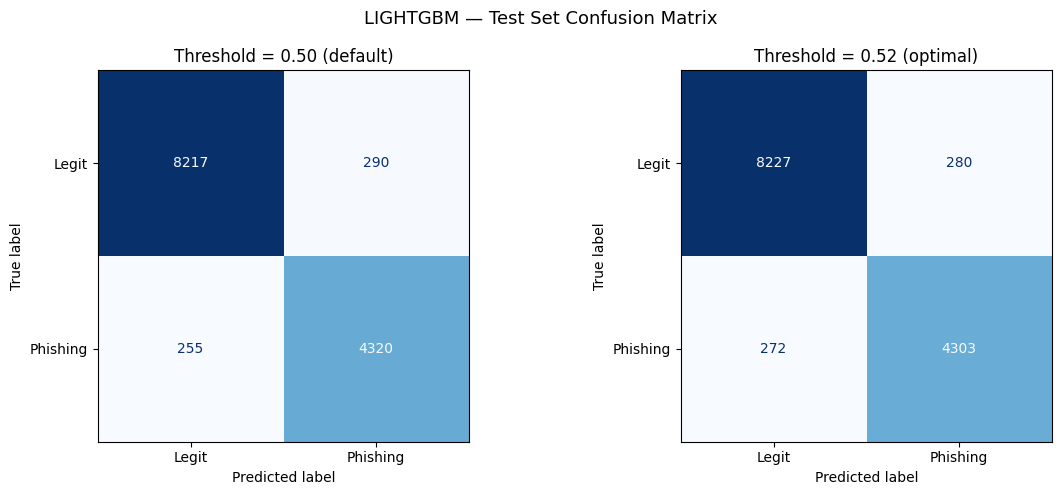

In [19]:
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_prob_test = final_model.predict_proba(X_test)[:, 1]

y_pred_default = (y_prob_test >= 0.50).astype(int)
y_pred_optimal = (y_prob_test >= optimal_thr).astype(int)

test_metrics = {
    "roc_auc" : roc_auc_score(y_test, y_prob_test),
    "f1_default"  : f1_score(y_test, y_pred_default),
    "f1_optimal"  : f1_score(y_test, y_pred_optimal),
    "accuracy": accuracy_score(y_test, y_pred_optimal),
}

print("\n" + "="*50)
print("  FINAL TEST SET RESULTS")
print("  (Test set dievaluasi hanya SEKALI ini)")
print("="*50)
for k, v in test_metrics.items():
    print(f"  {k:<20}: {v:.4f}")
print()
print(classification_report(y_test, y_pred_optimal,
                             target_names=["Legitimate", "Phishing"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in [
    (axes[0], y_pred_default, "Threshold = 0.50 (default)"),
    (axes[1], y_pred_optimal, f"Threshold = {optimal_thr:.2f} (optimal)"),
]:
    cm   = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Phishing"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)

plt.suptitle(f"{champion_name.upper()} — Test Set Confusion Matrix",
             fontsize=13)
plt.tight_layout()
plt.savefig("reports/confusion_matrix_final.png", dpi=150,
            bbox_inches="tight")
plt.show()

Simpan Model dan Artifacts

In [21]:
import joblib
import json
import pickle
from pathlib import Path
from mltools.registry import ModelRegistry
from mltools.shared.schemas import TrainingResult

Path("models").mkdir(parents=True, exist_ok=True)

joblib.dump(
    final_model,
    f"models/{champion_name}_champion.joblib",
    compress=3,
)

result = TrainingResult(
    champion_name  = champion_name,
    champion_model = final_model,
    all_scores     = all_scores,
    test_metrics   = test_metrics,
    model_path     = f"models/{champion_name}_champion.joblib",
    feature_names  = X_train.columns.tolist(),
    best_params    = best_params,
)

with open("models/training_result.pkl", "wb") as f:
    pickle.dump(result, f)

modeling_meta = {
    "champion_name"     : champion_name,
    "champion_model_path": f"models/{champion_name}_champion.joblib",
    "training_result_path": "models/training_result.pkl",
    "all_scores"        : {k: round(float(v), 6)
                          for k, v in all_scores.items()},
    "test_metrics"      : {k: round(float(v), 6)
                          for k, v in test_metrics.items()},
    "best_params"       : {k: str(v) for k, v in best_params.items()},
    "optimal_threshold" : float(optimal_thr),
    "feature_names"     : X_train.columns.tolist(),
    "n_features"        : len(X_train.columns),
    "data_paths": {
        "X_train": "data/processed/X_train.parquet",
        "X_val"  : "data/processed/X_val.parquet",
        "X_test" : "data/processed/X_test.parquet",
        "y_train": "data/processed/y_train.parquet",
        "y_val"  : "data/processed/y_val.parquet",
        "y_test" : "data/processed/y_test.parquet",
    },
}

with open("models/modeling_meta.json", "w") as f:
    json.dump(modeling_meta, f, indent=2)

registry   = ModelRegistry(base_dir="models")
model_path = registry.save(result, is_champion=True)

print("\n" + "="*55)
print("  MODELING SELESAI — ARTIFACTS TERSIMPAN")
print("="*55)
print(f"  Champion     : {champion_name}")
print(f"  Test ROC-AUC : {test_metrics['roc_auc']:.4f}")
print(f"  Test F1      : {test_metrics['f1_optimal']:.4f}")
print(f"  Threshold    : {optimal_thr:.4f}")
print(f"\n  Files saved ke Drive:")
for p in ["models/modeling_meta.json",
          f"models/{champion_name}_champion.joblib",
          "models/training_result.pkl"]:
    if Path(p).exists():
        size = Path(p).stat().st_size / 1e6
        print(f"    {p} ({size:.2f} MB)")
print("="*55)

20:05:23 | SUCCESS  | mltools.registry.model_registry:110 | Model saved: models/lightgbm/v_20260316_200523/model.txt
20:05:23 | INFO     | mltools.registry.model_registry:111 |   Name    : lightgbm
20:05:23 | INFO     | mltools.registry.model_registry:112 |   Version : v_20260316_200523
20:05:23 | INFO     | mltools.registry.model_registry:113 |   Metrics : roc_auc=0.9915, f1_default=0.9407, f1_optimal=0.9397, accuracy=0.9578

  MODELING SELESAI — ARTIFACTS TERSIMPAN
  Champion     : lightgbm
  Test ROC-AUC : 0.9915
  Test F1      : 0.9397
  Threshold    : 0.5222

  Files saved ke Drive:
    models/modeling_meta.json (0.00 MB)
    models/lightgbm_champion.joblib (4.10 MB)
    models/training_result.pkl (9.18 MB)

Lanjutkan ke: interpretation.ipynb
